### Snowpark on AWS Sagemaker

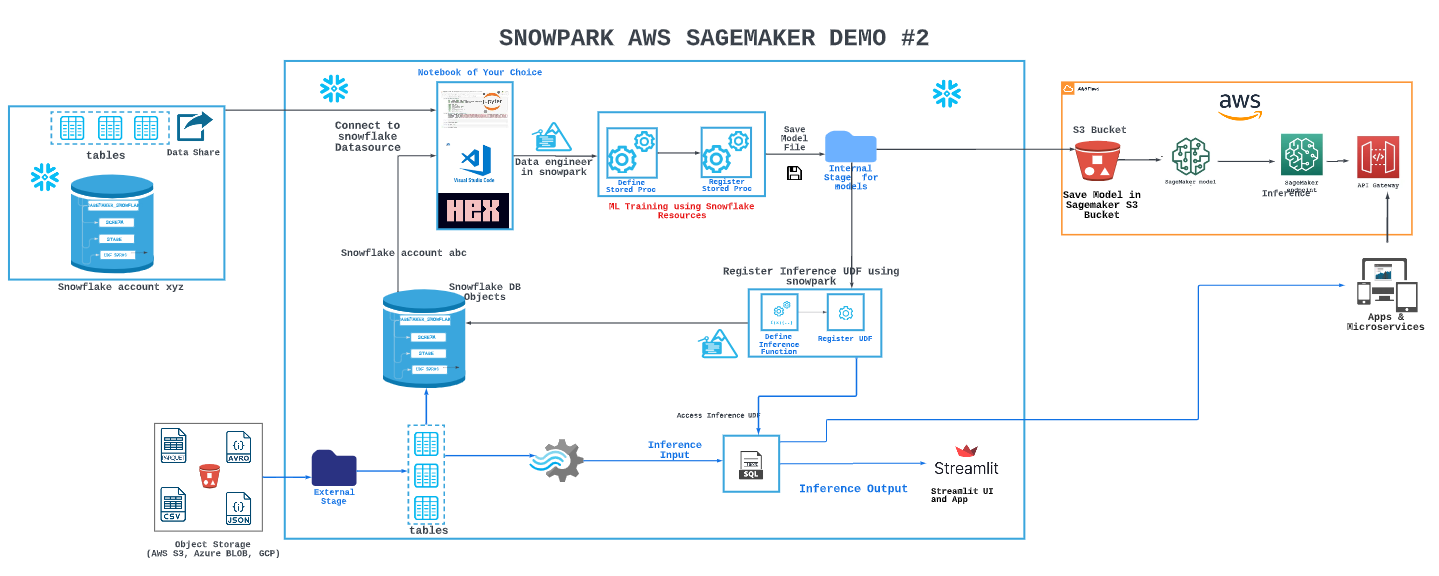

In [74]:
from IPython.display import Image
Image(filename='snowpark on AWS Sagemaker.png') 

### Install all the required libraries on Python 3.8 version and can be added to lifecycle Configuration

In [1]:
# Install Snowpark
!pip install snowflake-snowpark-python[pandas]==0.10.0

In [2]:
# Install Basic libraries
!pip install pandas==1.4.3
!pip install numpy==1.22.3
# Install ML libraries that will be used for this machine learning model
!pip install scikit-learn==1.1.1
!pip install lightgbm==3.2.1
!pip install xgboost==1.5.0
# Install Visualization libraries
!pip install scipy==1.7.1
!pip install seaborn==0.11.2
!pip install matplotlib
# Install other Misc libraries
!pip install cloudpickle==2.0.0
!pip install jupyter
!pip install cachetools==4.2.2

### Import all snowpark related libraries and check the version

In [1]:
from snowflake.snowpark.session import Session as snowpark_session
from snowflake.snowpark.functions import avg, sum, col,lit
from snowflake.snowpark.functions import udf, sproc, col, pandas_udf
from snowflake.snowpark import functions as F
from snowflake.snowpark import types as T
from snowflake.snowpark.types import IntegerType, FloatType, LongType,DoubleType, DecimalType,StringType, BooleanType, Variant
from snowflake.snowpark.types import PandasSeries, PandasDataFrame
from snowflake.snowpark import functions as fn
from snowflake.snowpark import version
print (f"snowflake snowpark version is: {version.VERSION}")

snowflake snowpark version is: (0, 10, 0)


### Import Other libraries

In [3]:
import urllib
import os
import io
import sys ,json
import io
import logging
import pandas as pd
import joblib
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Connect to Snowflake

In [103]:
snowflake_connection_cfg = open('cred.json')
snowflake_connection_cfg = snowflake_connection_cfg.read()
snowflake_connection_cfg = json.loads(snowflake_connection_cfg)

# Creating Snowpark Session

sf_session = snowpark_session.builder.configs(snowflake_connection_cfg).create()
print('Current Database:', sf_session.get_current_database())
print('Current Schema:', sf_session.get_current_schema())
print('Current Warehouse:', sf_session.get_current_warehouse())
sf_session.sql("use role accountadmin").collect()
print('Current role:', sf_session.get_current_role())
print("Warehouse set up:")
sf_session.sql("show warehouses like 'APP_WH'").collect()

Current Database: "SAGEMAKER_SNOWFLAKE_DEMO"
Current Schema: "PUBLIC"
Current Warehouse: "APP_WH"
Current role: "ACCOUNTADMIN"
Warehouse set up:


[Row(name='APP_WH', state='SUSPENDED', type='STANDARD', size='Medium', min_cluster_count=1, max_cluster_count=5, started_clusters=0, running=0, queued=0, is_default='N', is_current='Y', auto_suspend=600, auto_resume='true', available='', provisioning='', quiescing='', other='', created_on=datetime.datetime(2022, 2, 27, 4, 51, 57, 85000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), resumed_on=datetime.datetime(2023, 3, 2, 21, 20, 13, 570000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), updated_on=datetime.datetime(2023, 3, 2, 21, 20, 13, 570000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), owner='SYSADMIN', comment='', enable_query_acceleration='false', query_acceleration_max_scale_factor=8, resource_monitor='null', actives=0, pendings=0, failed=0, suspended=4, uuid='1463550724', scaling_policy='STANDARD')]

In [5]:
sf_session.sql("CREATE OR REPLACE STAGE deloitte_fed_stage_models").collect()
sf_session.sql("CREATE OR REPLACE STAGE deloitte_fed_stage_data").collect()

[Row(status='Stage area DELOITTE_FED_STAGE_DATA successfully created.')]

### Define the packages that will be required in snowpark

In [56]:
sf_session.clear_packages()
sf_session.add_packages("snowflake-snowpark-python")
sf_session.add_packages("scikit-learn","pandas","numpy","joblib","cachetools")
sf_session.clear_imports()
# staples_session.add_import(ge_import_path)

### Define the features that will be used as input

In [57]:
features=["RECENCY_DAY",
"FREQUENCY",
"MONETORY",
"RMF_SCORE",
"DOTCOM",
"REWARDS_ACCOUNT",
"FREQ_1",
"FREQ_2",
"FREQ_3",
"FREQ_4",
"FREQ_5",
"FREQ_6",
"FREQ_7",
"FREQ_8",
"FREQ_9",
"FREQ_10",
"FREQ_11",
"FREQ_12",
"CNT_PER_PDT",
"CNT_PER_PDT_SFC",
"CNT_PER_PDT_VFC",
"NO_DISCOUNT",
"DISCOUNT_PROMOTION",
"SUM_DIS_PRO"]

### Define the helper functions to Save model file in internal stage, Classification report & model info in snowflake table

In [58]:
def save_file(session, model, path, dest_filename):
    # logger.debug('#save_file: -- START--')
    input_stream = io.BytesIO()
    joblib.dump(model, input_stream)
    session._conn.upload_stream(input_stream, path, dest_filename)
    return "successfully created file: " + path

In [59]:
def get_classification_report(y_test, y_pred):
    from sklearn import metrics
    report = metrics.classification_report(y_test, y_pred, output_dict=True,target_names=['0','1'])
    df_classification_report = pd.DataFrame(report).transpose()    
    return df_classification_report

In [60]:
def get_model_info(model_name, test_size, random_state,ne,nj,cw,max_depth):
    data = [[model_name,test_size,random_state,ne,nj,cw,max_depth]]  
    df_model_info = pd.DataFrame(data,columns=['model','test_size','random_state','ne','nj','cw','max_depth'])
    return df_model_info

### Define the random forest Model pipeline using sklearn

In [61]:
def build_rf_model(p_df: pd.DataFrame,ne,nj,cw, md):
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.ensemble import RandomForestClassifier
    numeric_features = p_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = p_df.select_dtypes(include=['object']).columns.tolist()

    feature_names = numeric_features + categorical_features

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler(with_mean=True,with_std=True))])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])

    model = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier'
                    ,RandomForestClassifier(n_estimators=ne, n_jobs=-nj, class_weight=cw,max_depth=md)
                    # ,RandomForestClassifier(n_estimators=4, n_jobs=-1, class_weight='balanced_subsample',max_depth=20)
                    # ,RandomForestClassifier(maxBins=20,featureSubsetStrategy='onethird') need to find the equivalents
                    # of these maxBins and featureSubsetStrategy. For featureSubsetStrategy I do think it is the 
                    # classweight from sklearn based on the documentation. I also think maxBins could be the same as
                    # maxdepth.
                )
            ])

    return model


### Define the Main Function by calling the model pipeline and helper functions above

In [62]:
# def staples_train_rf_model(session: Session, training_table: str, sample_size_n: int, model_name: str,features:list, Y: str,test_size:float,random_state:int,ne:int,nj:int,cw:str, md:int) -> str:
def deloitte_fed_train_rf_model(session: snowpark_session, training_table: str, model_name: str,features:list, Y: str,test_size:float,random_state:int,ne:int,nj:int,cw:str, md:int) -> str:
    from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, RocCurveDisplay
    from sklearn import metrics
    import joblib
    # import matplotlib.pyplot as plt
#    training_data = session.table(training_table).sample(n=sample_size_n)
    training_data = session.table(training_table)

    Data_train, Data_test = training_data.random_split([1-test_size, test_size], seed=random_state)
    pd_Data_train=Data_train.to_pandas()
    pd_Data_test=Data_test.to_pandas()
    from sklearn.ensemble import RandomForestClassifier 
    # Model building
    rf = build_rf_model(pd_Data_train[features],ne,nj,cw, md)
    rf.fit(pd_Data_train[features], pd_Data_train[Y])

    model_dir = '@deloitte_fed_stage_models'
    model_fl = model_name+'.joblib'
    save_file(session, rf, model_dir ,model_fl)

    score = rf.score(pd_Data_test[features], pd_Data_test[Y])
    
    y_pred = rf.predict(pd_Data_test)
    df_classification_report = get_classification_report(y_pred,pd_Data_test[Y]).reset_index().rename(columns={"index": "class"}).reset_index(drop=True)
    df_model_info = get_model_info(model_fl,test_size,random_state,ne,nj,cw,md)
    df_model_info=df_model_info.append([df_model_info]*5,ignore_index=True)
    session.create_dataframe(df_classification_report.join(df_model_info)).write.mode("append").save_as_table("staples_model_output")
    
    return df_classification_report.join(df_model_info)

### Create the Model Output table to store the classification metrics which will be reviewed below

In [63]:
sf_session.sql("create or replace table deloitte_fed_model_output (class varchar, precision double, recall double, f1score double, support double, model varchar,test_size float, random_state int, ne int, nj int, cw varchar, max_depth int)").collect()

[Row(status='Table DELOITTE_FED_MODEL_OUTPUT successfully created.')]

### Register the above model main function as stored procedure

In [64]:
# Registering the function as a Stored Procedure
deloitte_fed_rf_sproc = sf_session.sproc.register(func=deloitte_fed_train_rf_model, # training function defined above
                                            name='deloitte_fed_rf_sproc', # training model name to be registered in snowlake
                                            is_permanent=True, # permanent stored proc
                                            replace=True, # replace if existing already
                                            stage_location='@deloitte_fed_stage_models', # save the model in stage location
                                            packages=['snowflake-snowpark-python','scikit-learn','joblib']) # import model libaries


### Verify the role and data we are going to use for Training

In [65]:
print('Current role:', sf_session.get_current_role())

Current role: "ACCOUNTADMIN"


In [66]:
sf_session.sql("select to_varchar(count(*), '999,999,999,999.00') as train_set_count from DELOITTE_FED_DATA_TRAIN").show()

-----------------------
|"TRAIN_SET_COUNT"    |
-----------------------
|       1,000,000.00  |
-----------------------



### Train the Model using the registered Stored Proc above

In [67]:
table_name = 'DELOITTE_FED_DATA_TRAIN'
test_size = 0.25
max_depth = 25
model_name = 'rf_deloitte_model'
random_state = 43,
n_estimator = 4
n_jobs = 1,
class_weight = 'balanced_subsample'
print ("random forest classifier report")
print (deloitte_fed_rf_sproc(table_name
                , model_name
                ,features
                ,'LABEL'
                ,test_size
                ,43
                ,n_estimator
                ,1
                ,class_weight
                , max_depth))

random forest classifier report
          class  precision    recall  ...  nj                  cw max_depth
0             0   0.677521  0.747571  ...   1  balanced_subsample        25
1             1   0.708502  0.632933  ...   1  balanced_subsample        25
2      accuracy   0.691144  0.691144  ...   1  balanced_subsample        25
3     macro avg   0.693011  0.690252  ...   1  balanced_subsample        25
4  weighted avg   0.692770  0.691144  ...   1  balanced_subsample        25

[5 rows x 12 columns]


### Check the classification metrics saved as a table in snowflake

In [68]:
sf_session.sql("""select class,precision,recall,f1score,model from staples_model_output order by f1score desc""").show(100)

----------------------------------------------------------------------------------------------------------
|"CLASS"       |"PRECISION"         |"RECALL"            |"F1SCORE"           |"MODEL"                   |
----------------------------------------------------------------------------------------------------------
|0             |0.6875222410430871  |0.7391953108261149  |0.7124230244478043  |rf_deloitte_model.joblib  |
|0             |0.6775205654700219  |0.7475711311589174  |0.7108241760301731  |rf_deloitte_model.joblib  |
|accuracy      |0.6911436705895544  |0.6911436705895544  |0.6911436705895544  |rf_deloitte_model.joblib  |
|weighted avg  |0.6927702007613225  |0.6911436705895544  |0.6900349799893783  |rf_deloitte_model.joblib  |
|macro avg     |0.6930111842758262  |0.6902519713782107  |0.6897064571473615  |rf_deloitte_model.joblib  |
|accuracy      |0.6886134779240899  |0.6886134779240899  |0.6886134779240899  |rf_deloitte_model.joblib  |
|weighted avg  |0.6887109615403922  |

In [69]:
### Verify if the Model is saved in internal stage

In [70]:
sf_session.sql("list @deloitte_fed_stage_models").collect()

[Row(name='deloitte_fed_stage_models/rf_deloitte_model.joblib', size=612912, md5='e08ec188d78a484d2ddf5a4b4d39c601', last_modified='Fri, 3 Mar 2023 05:21:44 GMT')]

### Check the stats on how long it took to train the model in snowflake

In [90]:
qry = '''select query_id,
       substr(query_text,55,20) model,
       warehouse_name,
       execution_status,
       TIMESTAMPDIFF(second,start_time,end_time) total_duration_in_secs
from table(information_schema.QUERY_HISTORY_BY_WAREHOUSE('APP_WH'))
WHERE query_text like '%deloitte_fed_rf_sproc%' and execution_status = 'SUCCESS'
order by TIMESTAMPDIFF(second,start_time,end_time) desc'''
sf_session.sql(qry).show(2)

----------------------------------------------------------------------------------------------------------------------------------
|"QUERY_ID"                            |"MODEL"               |"WAREHOUSE_NAME"  |"EXECUTION_STATUS"  |"TOTAL_DURATION_IN_SECS"  |
----------------------------------------------------------------------------------------------------------------------------------
|01aab121-0402-a160-0057-3c03034a0666  |'rf_deloitte_model',  |APP_WH            |SUCCESS             |37                        |
|01aab0fa-0402-a165-0057-3c03034943ea  |'rf_deloitte_model',  |APP_WH            |SUCCESS             |23                        |
----------------------------------------------------------------------------------------------------------------------------------



### Register UDF For Inference Using the Model file saved in internal Stage

In [91]:
import sys
import cachetools
import os
from snowflake.snowpark.functions import udf
sf_session.add_import("@deloitte_fed_stage_models/rf_deloitte_model.joblib")  

@cachetools.cached(cache={})
def read_file(filename):
       import_dir = sys._xoptions.get("snowflake_import_directory")
       if import_dir:
              with open(os.path.join(import_dir, filename), 'rb') as file:
                     m = joblib.load(file)
                     return m

@udf(name="predict_rf_deloitte_model", is_permanent=True, stage_location="@deloitte_fed_stage_models", replace=True)
def predict(RECENCY_DAY: float, FREQUENCY: float, MONETORY: float, RMF_SCORE: float, DOTCOM: float, REWARDS_ACCOUNT: float,
            FREQ_1: float, FREQ_2: float, FREQ_3: float, FREQ_4: float, FREQ_5: float, FREQ_6: float, FREQ_7: float, 
            FREQ_8: float, FREQ_9: float, FREQ_10: float, FREQ_11: float, FREQ_12: float, CNT_PER_PDT: float, 
            CNT_PER_PDT_SFC: float, CNT_PER_PDT_VFC: float, NO_DISCOUNT: float, DISCOUNT_PROMOTION: float,
            SUM_DIS_PRO: float) -> float:
       m = read_file('rf_deloitte_model.joblib')       
       row = pd.DataFrame([locals()], columns=features)
       return m.predict(row)[0]

### SQL Based Inference

In [92]:
qry="""SELECT 
       ACCT_NMB,
       LABEL AS ORIGINAL_LABEL,
       predict_rf_deloitte_model(RECENCY_DAY,FREQUENCY, MONETORY,RMF_SCORE,DOTCOM,REWARDS_ACCOUNT,
       FREQ_1,FREQ_2, FREQ_3, FREQ_4, FREQ_5, FREQ_6, FREQ_7, FREQ_8, FREQ_9, FREQ_10, FREQ_11, FREQ_12,
       CNT_PER_PDT, CNT_PER_PDT_SFC, CNT_PER_PDT_VFC, NO_DISCOUNT, DISCOUNT_PROMOTION, SUM_DIS_PRO) as PRED_rf_LABEL
        FROM (deloitte_fed_data_train) limit 1000"""
predict_snowpark_df = sf_session.sql(qry)
predict_snowpark_df.show(100)

---------------------------------------------------
|"ACCT_NMB"  |"ORIGINAL_LABEL"  |"PRED_RF_LABEL"  |
---------------------------------------------------
|3847669     |1                 |1.0              |
|5051815     |1                 |1.0              |
|6763277     |1                 |1.0              |
|9653        |0                 |1.0              |
|5702543     |0                 |1.0              |
|8297590     |1                 |1.0              |
|7716189     |1                 |1.0              |
|5681528     |0                 |0.0              |
|5432194     |0                 |0.0              |
|2408629     |0                 |0.0              |
|7006585     |0                 |0.0              |
|7205053     |0                 |0.0              |
|5120521     |1                 |1.0              |
|1406159     |0                 |0.0              |
|4422964     |1                 |1.0              |
|7102620     |0                 |1.0              |
|6696951    

### Close the session

In [104]:
sf_session.close()

### Let's Begin Again by Building a new Tensorflow model for the Same Use Case

In [2]:
from snowflake.snowpark.session import Session as snowpark_session
from snowflake.snowpark.functions import avg, sum, col,lit
from snowflake.snowpark.functions import udf, sproc, col, pandas_udf
from snowflake.snowpark import functions as F
from snowflake.snowpark import types as T
from snowflake.snowpark.types import IntegerType, FloatType, LongType,DoubleType, DecimalType,StringType, BooleanType, Variant
from snowflake.snowpark.types import PandasSeries, PandasDataFrame
from snowflake.snowpark import functions as fn
from snowflake.snowpark import version
print (f"snowflake snowpark version is: {version.VERSION}")

snowflake snowpark version is: (0, 10, 0)


### Import other libraries

In [1]:
import urllib
import os
import io
import sys ,json
import io
import logging
import pandas as pd
import joblib
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Connect to snowflake

In [3]:
snowflake_connection_cfg = open('cred.json')
snowflake_connection_cfg = snowflake_connection_cfg.read()
snowflake_connection_cfg = json.loads(snowflake_connection_cfg)

'''
APP_WH XS
LAB_WH S
HMWH M optimized warehouse
DCR_MA_WH L
BANK1_WH XL
'''

# Creating Snowpark Session
sk_tf_session = snowpark_session.builder.configs(snowflake_connection_cfg).create()
print('Current Database:', sk_tf_session.get_current_database())
print('Current Schema:', sk_tf_session.get_current_schema())
print('Current Warehouse:', sk_tf_session.get_current_warehouse())
sk_tf_session.sql("use role accountadmin").collect()
print('Current Warehouse:', sk_tf_session.get_current_warehouse())
print("Warehouse set up:")
sk_tf_session.sql("show warehouses like 'APP_WH'").collect()

Current Database: "SAGEMAKER_SNOWFLAKE_DEMO"
Current Schema: "PUBLIC"
Current Warehouse: "APP_WH"
Current Warehouse: "APP_WH"
Warehouse set up:


[Row(name='APP_WH', state='STARTED', type='STANDARD', size='Medium', min_cluster_count=1, max_cluster_count=5, started_clusters=1, running=0, queued=0, is_default='N', is_current='Y', auto_suspend=600, auto_resume='true', available=' 100', provisioning='0', quiescing='0', other='0', created_on=datetime.datetime(2022, 2, 27, 4, 51, 57, 85000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), resumed_on=datetime.datetime(2023, 3, 2, 21, 51, 55, 151000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), updated_on=datetime.datetime(2023, 3, 2, 21, 51, 55, 151000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), owner='SYSADMIN', comment='', enable_query_acceleration='false', query_acceleration_max_scale_factor=8, resource_monitor='null', actives=4, pendings=0, failed=0, suspended=0, uuid='1463550724', scaling_policy='STANDARD')]

### Let's add the packages required for this ML model

In [4]:
sk_tf_session.clear_packages()
sk_tf_session.add_packages("snowflake-snowpark-python")
sk_tf_session.add_packages("scikit-learn","pandas","numpy","joblib","cachetools","tensorflow","dill")
sk_tf_session.clear_imports()

package tensorflow is not installed in the local environmentYour UDF might not work when the package is installed on the server but not on your local environment.


### Define Helper Function to save model files .h5 and pipeline model file

In [5]:
def save_pipeline_tf_file(session, model ,classifier,modeldir, modelh5file, pipelinefile):
    import joblib
    import dill
    import os

    # collect the preprocessing pipeline & model seperately
    model_file = os.path.join('/tmp', modelh5file)
    classifier.model.save(model_file)
    session.file.put(model_file, modeldir,overwrite=True)

    # Upload  pipeline to a stage
    pipeline_file = os.path.join('/tmp', pipelinefile)
    input_stream = io.BytesIO()
    dill.dump(model, open(pipeline_file, "wb"))
    session.file.put(pipeline_file, modeldir,overwrite=True)
    return f"successfully uploaded model file: {modelh5file} and pipeline file : {pipelinefile}"

### Define Features Again

In [6]:
features=["RECENCY_DAY",
"FREQUENCY",
"MONETORY",
"RMF_SCORE",
"DOTCOM",
"REWARDS_ACCOUNT",
"FREQ_1",
"FREQ_2",
"FREQ_3",
"FREQ_4",
"FREQ_5",
"FREQ_6",
"FREQ_7",
"FREQ_8",
"FREQ_9",
"FREQ_10",
"FREQ_11",
"FREQ_12",
"CNT_PER_PDT",
"CNT_PER_PDT_SFC",
"CNT_PER_PDT_VFC",
"NO_DISCOUNT",
"DISCOUNT_PROMOTION",
"SUM_DIS_PRO"]

### Define sklearn pipeline for tensorflow keras classifier model

In [7]:
def build_tf_model(p_df: pd.DataFrame):
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    import tensorflow as tf
    from tensorflow.keras import layers
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
    from tensorflow.keras import datasets, layers, models
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
    numeric_features = p_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = p_df.select_dtypes(include=['object']).columns.tolist()
    
    feature_names = numeric_features + categorical_features

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler(with_mean=True,with_std=True))])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])
    def kerasclassifiermodel():
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization

        clf = Sequential()
        # clf.add(Dense(2, activation='relu', input_dim=24))
        # clf.add(Dense(2, activation='relu'))
        # clf.add(Dense(2, activation='sigmoid'))
        clf.add(Dense(units = 10 , activation = 'relu'))
        clf.add(Dropout(0.2))
        clf.add(Dense(units = 1 , activation = 'sigmoid')) # Tanh
        clf.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=["accuracy"])
        return clf

    model = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier'
                    ,KerasClassifier(kerasclassifiermodel)
                )
            ])

    return model

### Define Helper functions to capture classification reports and metrics in a snowflake table

In [8]:
def get_classification_report(y_test, y_pred):
    from sklearn import metrics
    report = metrics.classification_report(y_test, y_pred, output_dict=True,target_names=['0','1'])
    df_classification_report = pd.DataFrame(report).transpose()    
    return df_classification_report

In [9]:
def get_model_info(model_name, test_size, random_state,epochs,batchsize):
    data = [[model_name,test_size,random_state,epochs,batchsize]]  
    df_model_info = pd.DataFrame(data,columns=['model','test_size','random_state','epochs','batchsize'])
    return df_model_info

### Define Main function to assemble all the steps in tensorflow

In [24]:
def deloitte_fed_train_tf_model(session: snowpark_session, training_table: str, model_name: str,features:list, Y: str,test_size:float,random_state:int,epochs:int,batchsize:int) -> str:
    from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, RocCurveDisplay
    from tensorflow.keras.callbacks import EarlyStopping

    # Load training data
    training_data = session.table(training_table)

    # Train test split
    Data_train, Data_test = training_data.random_split([1-test_size, test_size], seed=random_state)
    pd_Data_train=Data_train.to_pandas()
    pd_Data_test=Data_test.to_pandas()

    # Model building
    tf = build_tf_model(pd_Data_train[features])

    # define early stopping
    early_stopping = EarlyStopping()
    custom_early_stopping = [
        EarlyStopping(
        monitor='loss', 
        patience=10, 
        mode='auto'
    )]
    
    # Model training
    tf.fit(pd_Data_train[features], pd_Data_train[Y], 
           classifier__epochs=epochs, 
           classifier__batch_size=batchsize, 
           classifier__verbose=1,
           classifier__callbacks=[custom_early_stopping])


    # Upload  model to a stage
    save_pipeline_tf_file(session,tf, 
                 tf.named_steps['classifier'], 
                 "@deloitte_fed_stage_models", 
                 model_name+"keras_model_1M.h5", 
                 model_name+"sklearn_pipe_1M.pkl")
    
    # Score Model
    score = tf.score(pd_Data_test[features], pd_Data_test[Y])
    
    y_pred = tf.predict(pd_Data_test)
    
    #Evaluate Metrics
    df_classification_report = get_classification_report(y_pred,pd_Data_test[Y]).reset_index().rename(columns={"index": "class"}).reset_index(drop=True)
    df_model_info = get_model_info('keras_model_1M.h5',test_size,random_state,epochs,batchsize)
    df_model_info=df_model_info.append([df_model_info]*5,ignore_index=True)
    session.create_dataframe(df_classification_report.join(df_model_info)).write.mode("append").save_as_table("STAPLES_TF_MODEL_OUTPUT")
    
    print (f"model score on validation data: {score}")
    return df_classification_report.join(df_model_info)

### Register model as Stored Proc

In [25]:
# Registering the function as a Stored Procedure
deloitte_fed_tf_sproc = sk_tf_session.sproc.register(func=deloitte_fed_train_tf_model, # training function defined above
                                            name='deloitte_fed_train_tf_model', # training model name to be registered in snowlake
                                            is_permanent=True, # permanent stored proc
                                            replace=True, # replace if existing already
                                            stage_location='@deloitte_fed_stage_models', # save the model in stage location
                                            packages=['snowflake-snowpark-python','scikit-learn','joblib','dill','tensorflow']) # import model libaries

package tensorflow is not installed in the local environmentYour UDF might not work when the package is installed on the server but not on your local environment.


### Since tensorflow model is memory intensive let's use Snowpark optimized warehouse

In [22]:
sk_tf_session.sql("use warehouse HMWH").collect()
print('Current Warehouse:', sk_tf_session.get_current_warehouse())
print("Warehouse set up:")
sk_tf_session.sql("show warehouses like 'HMWH'").collect()

Current Warehouse: "HMWH"
Warehouse set up:


[Row(name='HMWH', state='SUSPENDED', type='SNOWPARK-OPTIMIZED', size='Medium', min_cluster_count=1, max_cluster_count=1, started_clusters=0, running=0, queued=0, is_default='N', is_current='Y', auto_suspend=300, auto_resume='true', available='', provisioning='', quiescing='', other='', created_on=datetime.datetime(2022, 11, 1, 18, 18, 59, 3000, tzinfo=<DstTzInfo 'America/Los_Angeles' PDT-1 day, 17:00:00 DST>), resumed_on=datetime.datetime(2023, 1, 26, 21, 13, 4, 447000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), updated_on=datetime.datetime(2023, 1, 26, 21, 13, 4, 447000, tzinfo=<DstTzInfo 'America/Los_Angeles' PST-1 day, 16:00:00 STD>), owner='SYSADMIN', comment='warehouse used by role dev_blogger', enable_query_acceleration='false', query_acceleration_max_scale_factor=8, resource_monitor='null', actives=0, pendings=0, failed=0, suspended=1, uuid='1463550932', scaling_policy='STANDARD')]

### Check the record count on train set

In [30]:
sk_tf_session.sql("select count(*) from deloitte_fed_data_train").collect()

[Row(COUNT(*)=1000000)]

### Train the model @30 epochs on 1 Million row data

In [28]:
# table_name = 'staples_data_train_15M'
# table_name = 'staples_data_train'
table_name = 'deloitte_fed_data_train'
test_size = 0.25
model_name = 'tf_deloitte_model'
random_state = 43,
epochs=100,
batchsize=100
print ("Tensorflow classifier report")
print (deloitte_fed_tf_sproc(table_name
                , model_name
                ,features
                ,'LABEL'
                ,test_size
                ,43
                ,30
                ,100))

Tensorflow classifier report
          class  precision    recall  ...  random_state  epochs batchsize
0             0   0.832768  0.719695  ...            43      30       100
1             1   0.585941  0.732949  ...            43      30       100
2      accuracy   0.724349  0.724349  ...            43      30       100
3     macro avg   0.709355  0.726322  ...            43      30       100
4  weighted avg   0.746095  0.724349  ...            43      30       100

[5 rows x 10 columns]


### Check the model files saved, Look for .h5 and .pkl files

In [29]:
sk_tf_session.sql("list @deloitte_fed_stage_models").collect()

[Row(name='deloitte_fed_stage_models/deloitte_fed_train_tf_model/udf_py_1044899756.zip', size=3680, md5='871b15bf6a69d2c710738536f6662c70', last_modified='Fri, 3 Mar 2023 06:00:44 GMT'),
 Row(name='deloitte_fed_stage_models/deloitte_fed_train_tf_model/udf_py_1142546445.zip', size=3680, md5='b4959846cc1dd283cda996278d2a2d26', last_modified='Fri, 3 Mar 2023 06:32:15 GMT'),
 Row(name='deloitte_fed_stage_models/deloitte_fed_train_tf_model/udf_py_1228099523.zip', size=3680, md5='fa9389c510ca9fedf05837b102fc0c22', last_modified='Fri, 3 Mar 2023 05:56:12 GMT'),
 Row(name='deloitte_fed_stage_models/deloitte_fed_train_tf_model/udf_py_1880519692.zip', size=3680, md5='808e07a88b28d98dd48222577990b69e', last_modified='Fri, 3 Mar 2023 06:02:07 GMT'),
 Row(name='deloitte_fed_stage_models/deloitte_fed_train_tf_model/udf_py_2121299512.zip', size=3664, md5='291ec22104097c825f4007d4dab7bee7', last_modified='Fri, 3 Mar 2023 06:30:39 GMT'),
 Row(name='deloitte_fed_stage_models/rf_deloitte_model.joblib', s

### Now we can go back to using a standard warehouse

In [31]:
sk_tf_session.sql("use warehouse app_wh").collect()

[Row(status='Statement executed successfully.')]

### Check the model output on all the training iterations

In [46]:
sk_tf_session.sql("""select "class","precision","recall","f1-score","model" from STAPLES_TF_MODEL_OUTPUT""").show(100)

---------------------------------------------------------------------------------------------------
|"class"       |"precision"         |"recall"            |"f1-score"          |"model"            |
---------------------------------------------------------------------------------------------------
|0             |0.9130434782608695  |0.786096256684492   |0.8448275862068965  |keras_model_1M.h5  |
|1             |0.5121951219512195  |0.75                |0.6086956521739131  |keras_model_1M.h5  |
|accuracy      |0.7777777777777778  |0.7777777777777778  |0.7777777777777778  |keras_model_1M.h5  |
|macro avg     |0.7126193001060446  |0.768048128342246   |0.7267616191904047  |keras_model_1M.h5  |
|weighted avg  |0.8206669023211971  |0.7777777777777778  |0.7904103503803653  |keras_model_1M.h5  |
|0             |0.8509316770186336  |0.8106508875739645  |0.8303030303030303  |keras_model_1M.h5  |
|1             |0.6097560975609756  |0.6756756756756757  |0.6410256410256411  |keras_model_1M.h5  |


### Check all the executions in snowflake

In [58]:
qry = '''select query_id,
       substr(query_text,5,28) model,
       warehouse_name,
       TIMESTAMPDIFF(second,start_time,end_time) total_duration
from table(information_schema.QUERY_HISTORY_BY_WAREHOUSE('HMWH'))
WHERE query_text like '%CALL%' and execution_status ='SUCCESS' and
TIMESTAMPDIFF(second,start_time,end_time) > 10
order by start_time desc'''
sk_tf_session.sql(qry).show()

-------------------------------------------------------------------------------------------------------------
|"QUERY_ID"                            |"MODEL"                       |"WAREHOUSE_NAME"  |"TOTAL_DURATION"  |
-------------------------------------------------------------------------------------------------------------
|01aab169-0402-a165-0057-3c03034c0d3e  | deloitte_fed_train_tf_model  |HMWH              |550               |
|01aab168-0402-a160-0057-3c03034b85da  | deloitte_fed_train_tf_model  |HMWH              |14                |
|01aab168-0402-a165-0057-3c03034c06aa  | deloitte_fed_train_tf_model  |HMWH              |12                |
-------------------------------------------------------------------------------------------------------------



### Import the trained model files from internal stage

In [63]:
import sys
import cachetools
import os
import joblib
from snowflake.snowpark.functions import udf
sk_tf_session.clear_imports()
sk_tf_session.add_import("@deloitte_fed_stage_models/tf_deloitte_modelkeras_model_1M.h5")  
sk_tf_session.add_import("@deloitte_fed_stage_models/tf_deloitte_modelsklearn_pipe_1M.pkl")  

### Register UDF Using the model files in internal stage

In [66]:
@cachetools.cached(cache={})
def read_file(filename):
       import_dir = sys._xoptions.get("snowflake_import_directory")
       if import_dir:
              with open(os.path.join(import_dir, filename), 'rb') as file:
                     m = joblib.load(file)
                     return m

@udf(name="predict_tf_deloitte_model", is_permanent=True, stage_location="@deloitte_fed_stage_models", replace=True)
def predict(RECENCY_DAY: float, FREQUENCY: float, MONETORY: float, RMF_SCORE: float, DOTCOM: float, REWARDS_ACCOUNT: float,
            FREQ_1: float, FREQ_2: float, FREQ_3: float, FREQ_4: float, FREQ_5: float, FREQ_6: float, FREQ_7: float, 
            FREQ_8: float, FREQ_9: float, FREQ_10: float, FREQ_11: float, FREQ_12: float, CNT_PER_PDT: float, 
            CNT_PER_PDT_SFC: float, CNT_PER_PDT_VFC: float, NO_DISCOUNT: float, DISCOUNT_PROMOTION: float,
            SUM_DIS_PRO: float) -> int:
       m = read_file('tf_deloitte_modelsklearn_pipe_1M.pkl')       
       row = pd.DataFrame([locals()], columns=features)
       return m.predict(row)[0]

### Define the features

In [65]:
features = ['RECENCY_DAY',
'FREQUENCY',
'MONETORY',
'RMF_SCORE',
'DOTCOM',
'REWARDS_ACCOUNT',
'FREQ_1',
'FREQ_2',
'FREQ_3',
'FREQ_4',
'FREQ_5',
'FREQ_6',
'FREQ_7',
'FREQ_8',
'FREQ_9',
'FREQ_10',
'FREQ_11',
'FREQ_12',
'CNT_PER_PDT',
'CNT_PER_PDT_SFC',
'CNT_PER_PDT_VFC',
'NO_DISCOUNT',
'DISCOUNT_PROMOTION',
'SUM_DIS_PRO',
'LABEL']

### Query using both the models we have built and registered as UDFs

In [67]:
qry="""SELECT 
       substr(ACCT_NMB,5,5) ACCT_NMB,
       LABEL AS ORIGINAL_LABEL,
       predict_tf_deloitte_model(RECENCY_DAY,FREQUENCY, MONETORY,RMF_SCORE,DOTCOM,REWARDS_ACCOUNT,
       FREQ_1,FREQ_2, FREQ_3, FREQ_4, FREQ_5, FREQ_6, FREQ_7, FREQ_8, FREQ_9, FREQ_10, FREQ_11, FREQ_12,
       CNT_PER_PDT, CNT_PER_PDT_SFC, CNT_PER_PDT_VFC, NO_DISCOUNT, DISCOUNT_PROMOTION, SUM_DIS_PRO) as PRED_tf_LABEL,
       predict_rf_deloitte_model(RECENCY_DAY,FREQUENCY, MONETORY,RMF_SCORE,DOTCOM,REWARDS_ACCOUNT,
       FREQ_1,FREQ_2, FREQ_3, FREQ_4, FREQ_5, FREQ_6, FREQ_7, FREQ_8, FREQ_9, FREQ_10, FREQ_11, FREQ_12,
       CNT_PER_PDT, CNT_PER_PDT_SFC, CNT_PER_PDT_VFC, NO_DISCOUNT, DISCOUNT_PROMOTION, SUM_DIS_PRO) as PRED_rf_LABEL
        FROM (deloitte_fed_data_train) limit 100"""
predict_snowpark_df = sk_tf_session.sql(qry)
predict_snowpark_df.show(100)

---------------------------------------------------------------------
|"ACCT_NMB"  |"ORIGINAL_LABEL"  |"PRED_TF_LABEL"  |"PRED_RF_LABEL"  |
---------------------------------------------------------------------
|025         |0                 |0                |0.0              |
|388         |1                 |0                |0.0              |
|782         |0                 |0                |0.0              |
|224         |0                 |0                |0.0              |
|045         |0                 |0                |0.0              |
|992         |1                 |0                |0.0              |
|71          |1                 |0                |0.0              |
|919         |1                 |0                |0.0              |
|784         |1                 |0                |0.0              |
|728         |0                 |0                |0.0              |
|225         |1                 |0                |0.0              |
|225         |0     

In [71]:
sk_tf_session.close()